In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
path = "dataset"

In [3]:
os.chdir("..")
os.chdir("..")
os.chdir(path)

In [4]:
df = pd.read_csv('train.csv', sep = ',')

In [5]:
df.head(10)

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0
5,0083ee8054ee,4
6,0097f532ac9f,0
7,00a8624548a9,2
8,00b74780d31d,2
9,00cb6555d108,1


diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64

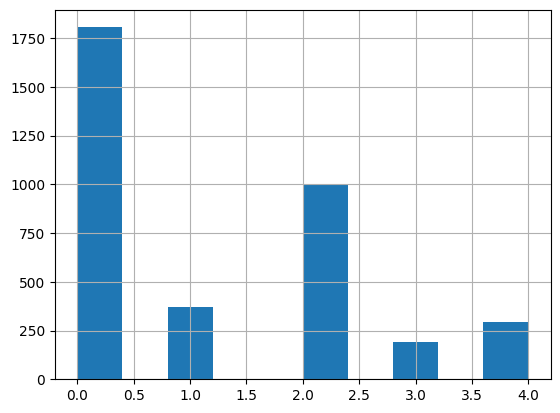

In [6]:
df['diagnosis'].hist()
df['diagnosis'].value_counts()

Retinopati görüntülerini aktarmak için, **os.listdir()** kullanarak *''train_images''* klasöründe bulunan dosyaların isimlerini *''files''* ismine atadım.
* '000c1434d8d7.png'
* '001639a390f0.png'
* '0024cdab0c1e.png'
*  ...

In [7]:
files = os.listdir('train_images')
# files

In [8]:
len(files)

3662

In [9]:
import cv2

OpenCV'nin [görüntü okuma modülü](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_gui/py_image_display/py_image_display.html)nü kullanarak **files**'ın içindeki görüntü isimleri üzerinden bir for döngüsü döndürerek görüntüleri okuduk. Ardından bunları (128,128,3) boyutunda yeniden şekillendirdik. OpenCV görüntüleri BGR şeklinde okuduğu için bunları RGB renk koduna çevirdik. Ardından döngüde dönen her görüntüyü *img_list* ismindeki listeye ekledik.

In [10]:
img_list = []

for i in files[0:20]:
    image = cv2.imread('train_images\\'+i)
    image = cv2.resize(image,(128,128))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_list.append(image)

In [11]:
import matplotlib.pyplot as plt

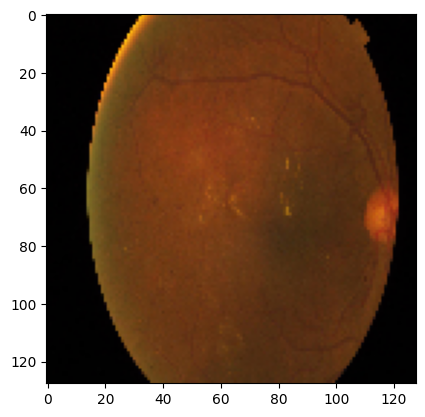

In [12]:
plt.imshow(img_list[0])

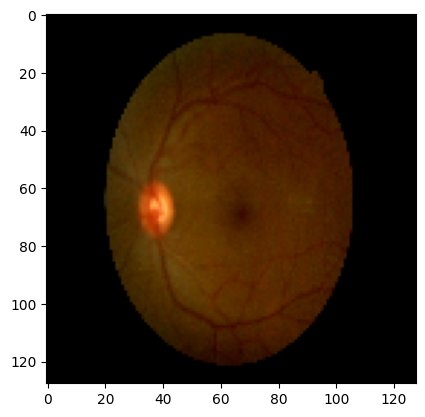

In [13]:
plt.imshow(img_list[4])

In [14]:
kopya = img_list[4].copy()

#### Threshold uygulayabilmek için görüntümüzü siyah-beyaz renklere çevirdik.

In [15]:
kopya = cv2.cvtColor(kopya, cv2.COLOR_RGB2GRAY)

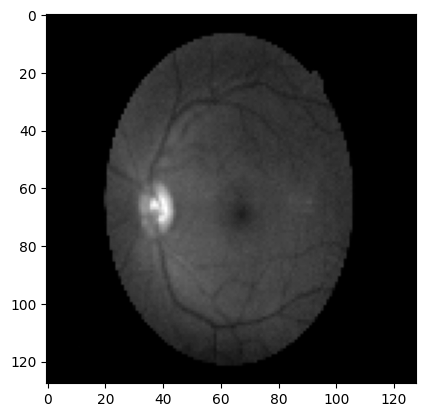

In [16]:
plt.imshow(kopya, cmap='gray')

#### Görüntü siyah beyaz olduğu için RGB kanallarını kaybederek (128,128) boyutuna indirgendi.

In [17]:
kopya.shape

(128, 128)

#### Threshold'un daha başarılı uygulanabilmesi için bir miktar Blur uyguluyoruz.

In [18]:
blur = cv2.GaussianBlur(kopya,(5,5),0)

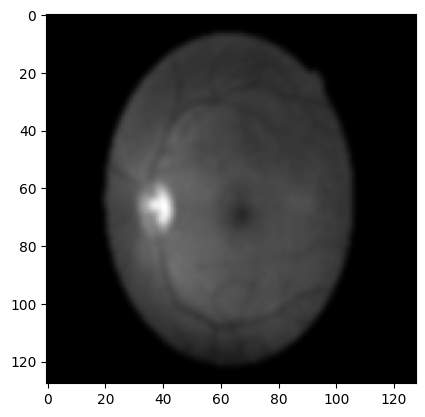

In [19]:
plt.imshow(blur,cmap='gray')

Burada görüntü üzerinde  **10 değerinin üzerinde bulduğu tüm değerleri 255 değerine eşitledik**

In [20]:
thresh = cv2.threshold(blur,10,255, cv2.THRESH_BINARY)[1]

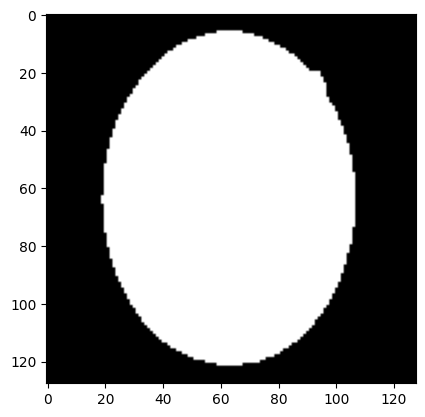

In [21]:
plt.imshow(thresh, cmap='gray')

Kırpma işlemini yapmak için elimizdeki yeni görüntünün **kenar koordinatlarını(kontur)** buluyoruz.

In [22]:
kontur = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [23]:
# kontur

In [24]:
 kontur = kontur[0][0]

In [25]:
kontur.shape

(151, 1, 2)

In [26]:
kontur = kontur[:,0,:]

In [27]:
kontur.shape

(151, 2)

In [28]:
# kontur

In [29]:
kontur[:,0].argmax()

111

In [30]:
kontur[:,0].argmin()

35

In [31]:
kontur[111]

array([106,  73], dtype=int32)

In [32]:
sol = tuple(kontur[kontur[:,0].argmin()])
sağ = tuple(kontur[kontur[:,0].argmax()])
üst = tuple(kontur[kontur[:,1].argmin()])
alt = tuple(kontur[kontur[:,1].argmax()])

Görüntümüzün **4 uç noktasına ait koordinatları**nı elde ettik.

In [33]:
sol, sağ, üst, alt

((19, 63), (106, 73), (59, 6), (59, 121))

In [34]:
x1 = sol[0]
y1 = üst[1]
x2 = sağ[0]
y2 = alt[1]

In [35]:
x1, y1, x2, y2

(19, 6, 106, 121)

In [36]:
orijinal = img_list[4].copy()

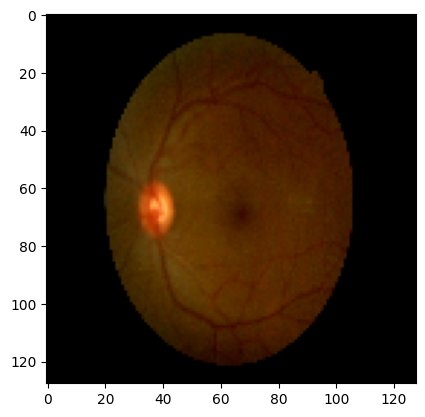

In [37]:
plt.imshow(orijinal)

In [38]:
crop_ilk = orijinal[y1:y2 , x1:x2]

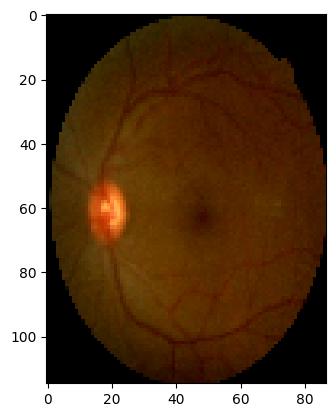

In [39]:
plt.imshow(crop_ilk)

In [40]:
crop_ilk.shape

(115, 87, 3)

Kıprma işlemini yaptıktan sonra görüntü boyut kayması yaşadığı için tekrardan (128,128) boyutuna eşitliyoruz.

In [41]:
crop_ilk = cv2.resize(crop_ilk,(128,128))

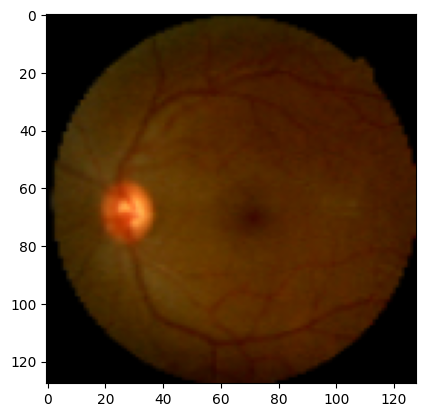

In [42]:
plt.imshow(crop_ilk)

Kenarlardaki veriler gereksiz olduğu için bir eşik belirleyip, bir miktar daha görüntüleri kırpıyoruz.

In [43]:
x = int(x2-x1)*4//100
y = int(y2-y1)*5//100

In [44]:
x,y

(3, 5)

In [45]:
crop_son = orijinal[y1+y : y2-y , x1+x : x2-x]

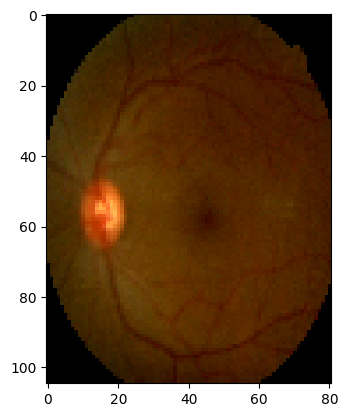

In [46]:
plt.imshow(crop_son)

In [47]:
crop_son = cv2.resize(crop_son,(128,128))

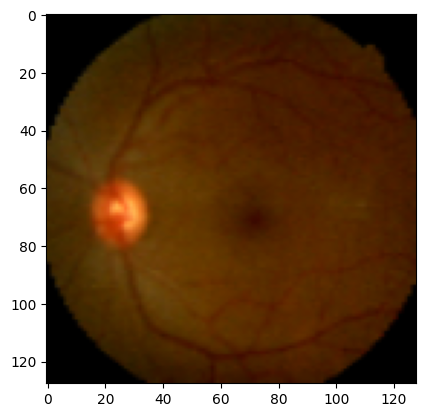

In [48]:
plt.imshow(crop_son)

## CLAHE - Kontrast Limitli Adaptif Histogram Eşitleme

CLAHE uygulamak için renk kanalını RGB'den LAB'a çeviriyoruz.

In [49]:
lab = cv2.cvtColor(crop_son, cv2.COLOR_RGB2LAB)

In [50]:
lab.shape

(128, 128, 3)

In [51]:
l,a,b = cv2.split(lab)

LAB'daki ''l'' görüntünün siyah-beyaz parlaklık değerini içeriyor. CLAHE işlemini sadece bu katmana uygulayacağız. 

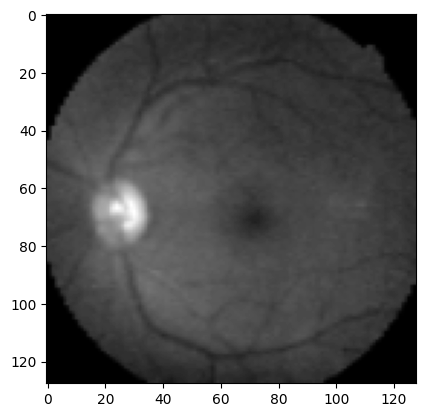

In [52]:
plt.imshow(l, cmap='gray')

In [53]:
l.shape

(128, 128)

In [54]:
düz = l.flatten()

In [55]:
düz.shape

(16384,)

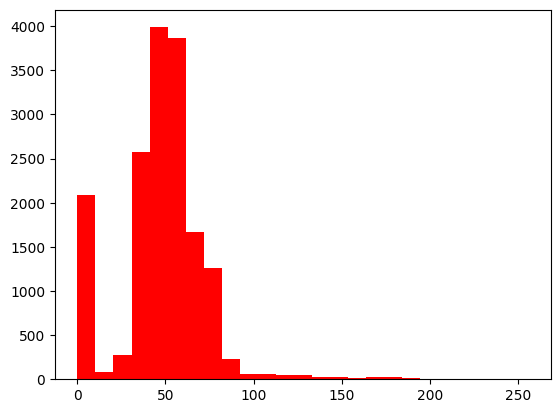

In [56]:
plt.hist(düz,25,[0,256], color = 'r')
plt.show()

In [57]:
clahe = cv2.createCLAHE(clipLimit=7.0,tileGridSize=((8,8)))
cl = clahe.apply(l)

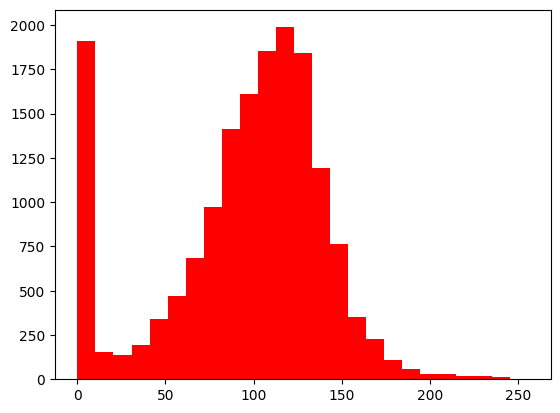

In [58]:
plt.hist(cl.flatten(),25,[0,256], color = 'r')
plt.show()

## CLAHE uygulanmış hali

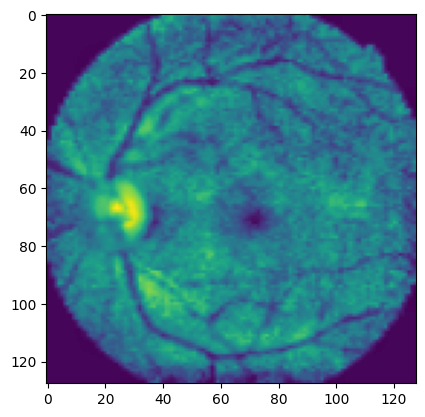

In [59]:
plt.imshow(cl)

## CLAHE uygulanmamış hali


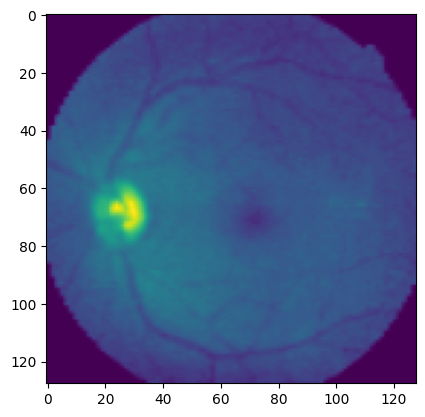

In [60]:
plt.imshow(l)

CLAHE işlemi uyguladığımız katmanı, diğer katmanlarla birleştirip tekrardan görüntümüzü RGB yapıyoruz.

In [61]:
limg = cv2.merge((cl,a,b))

In [62]:
son = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

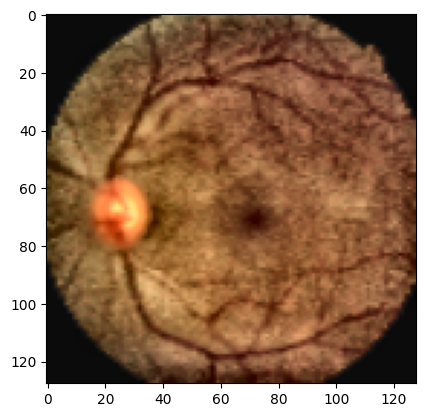

In [63]:
plt.imshow(son)

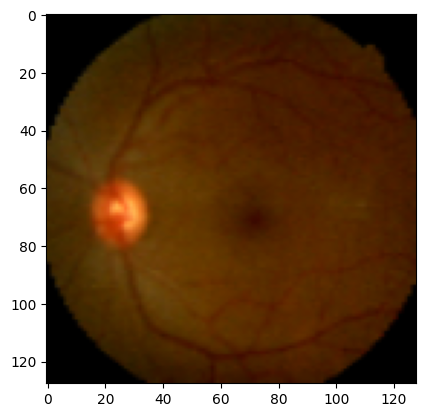

In [64]:
plt.imshow(crop_son)

## Median Blur

In [65]:
med_son = cv2.medianBlur(son, 3)

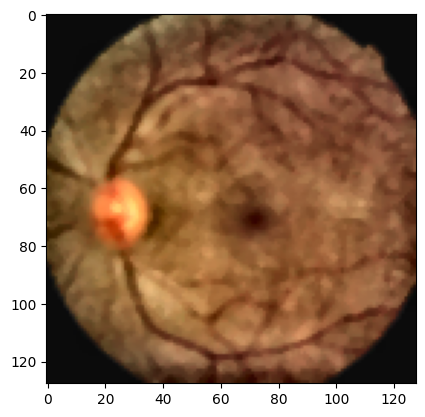

In [66]:
plt.imshow(med_son)

In [67]:
arka_plan = cv2.medianBlur(son, 37)

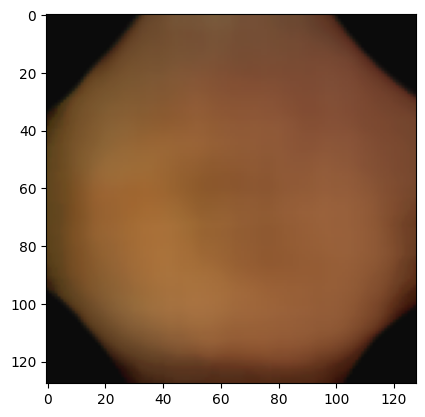

In [68]:
plt.imshow(arka_plan)

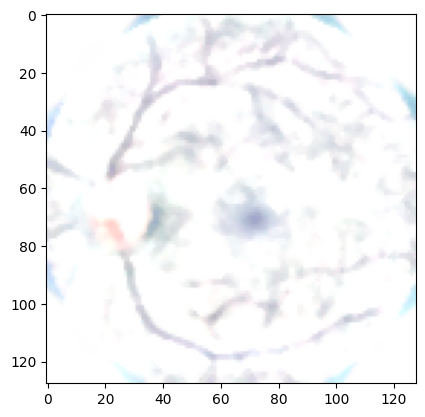

In [69]:
maske = cv2.addWeighted(med_son,1,arka_plan,-1,255)
plt.imshow(maske)

In [70]:
son_img = cv2.bitwise_and(maske,med_son)

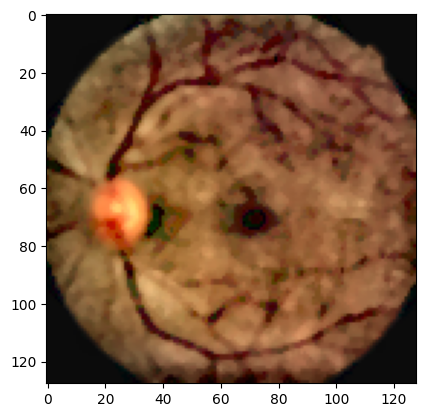

In [71]:
plt.imshow(son_img)

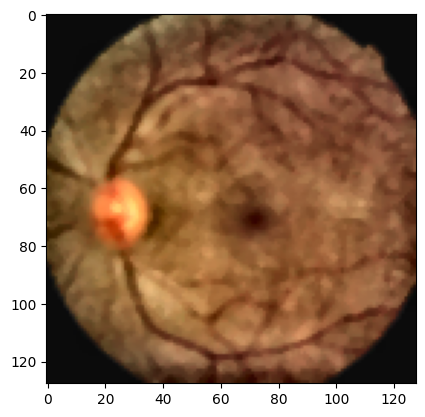

In [72]:
plt.imshow(med_son)

#### Yaptığımız tüm işlemleri tek bir for döngüsünde toplayıp, elimizdeki bütün görüntüleri bu döngüyle img_list ismindeki listeye kaydediyoruz.

In [73]:
img_list = []

from tqdm.notebook import tqdm

for i in tqdm(files):
    image = cv2.imread('train_images\\'+i)
    image = cv2.resize(image,(128,128))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    kopya = image.copy()
    kopya = cv2.cvtColor(kopya, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(kopya,(5,5),0)
    thresh = cv2.threshold(blur,10,255, cv2.THRESH_BINARY)[1]
    kontur = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    kontur = kontur[0][0]
    kontur = kontur[:,0,:]
    x1 = tuple(kontur[kontur[:,0].argmin()])[0]
    y1 = tuple(kontur[kontur[:,1].argmin()])[1]
    x2 = tuple(kontur[kontur[:,0].argmax()])[0]
    y2 = tuple(kontur[kontur[:,1].argmax()])[1]
    x = int(x2-x1)*4//50
    y = int(y2-y1)*5//50
    kopya2 = image.copy()
    if x2-x1 >100 and y2-y1> 100:
        kopya2 = kopya2[y1+y : y2-y , x1+x : x2-x]
        kopya2 = cv2.resize(kopya2,(128,128))
    lab = cv2.cvtColor(kopya2, cv2.COLOR_RGB2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=5.0,tileGridSize=((8,8)))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    son = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    med_son = cv2.medianBlur(son, 3)
    arka_plan = cv2.medianBlur(son, 37)
    maske = cv2.addWeighted(med_son,1,arka_plan,-1,255)
    son_img = cv2.bitwise_and(maske,med_son)
    img_list.append(son_img)

  0%|          | 0/3662 [00:00<?, ?it/s]

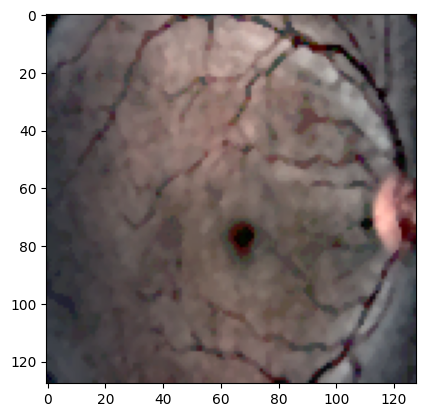

In [74]:
plt.imshow(img_list[6])

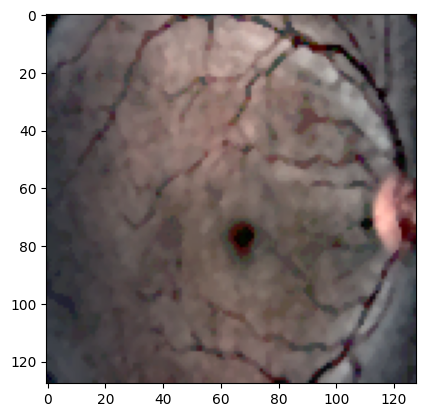

In [75]:
plt.imshow(img_list[6])

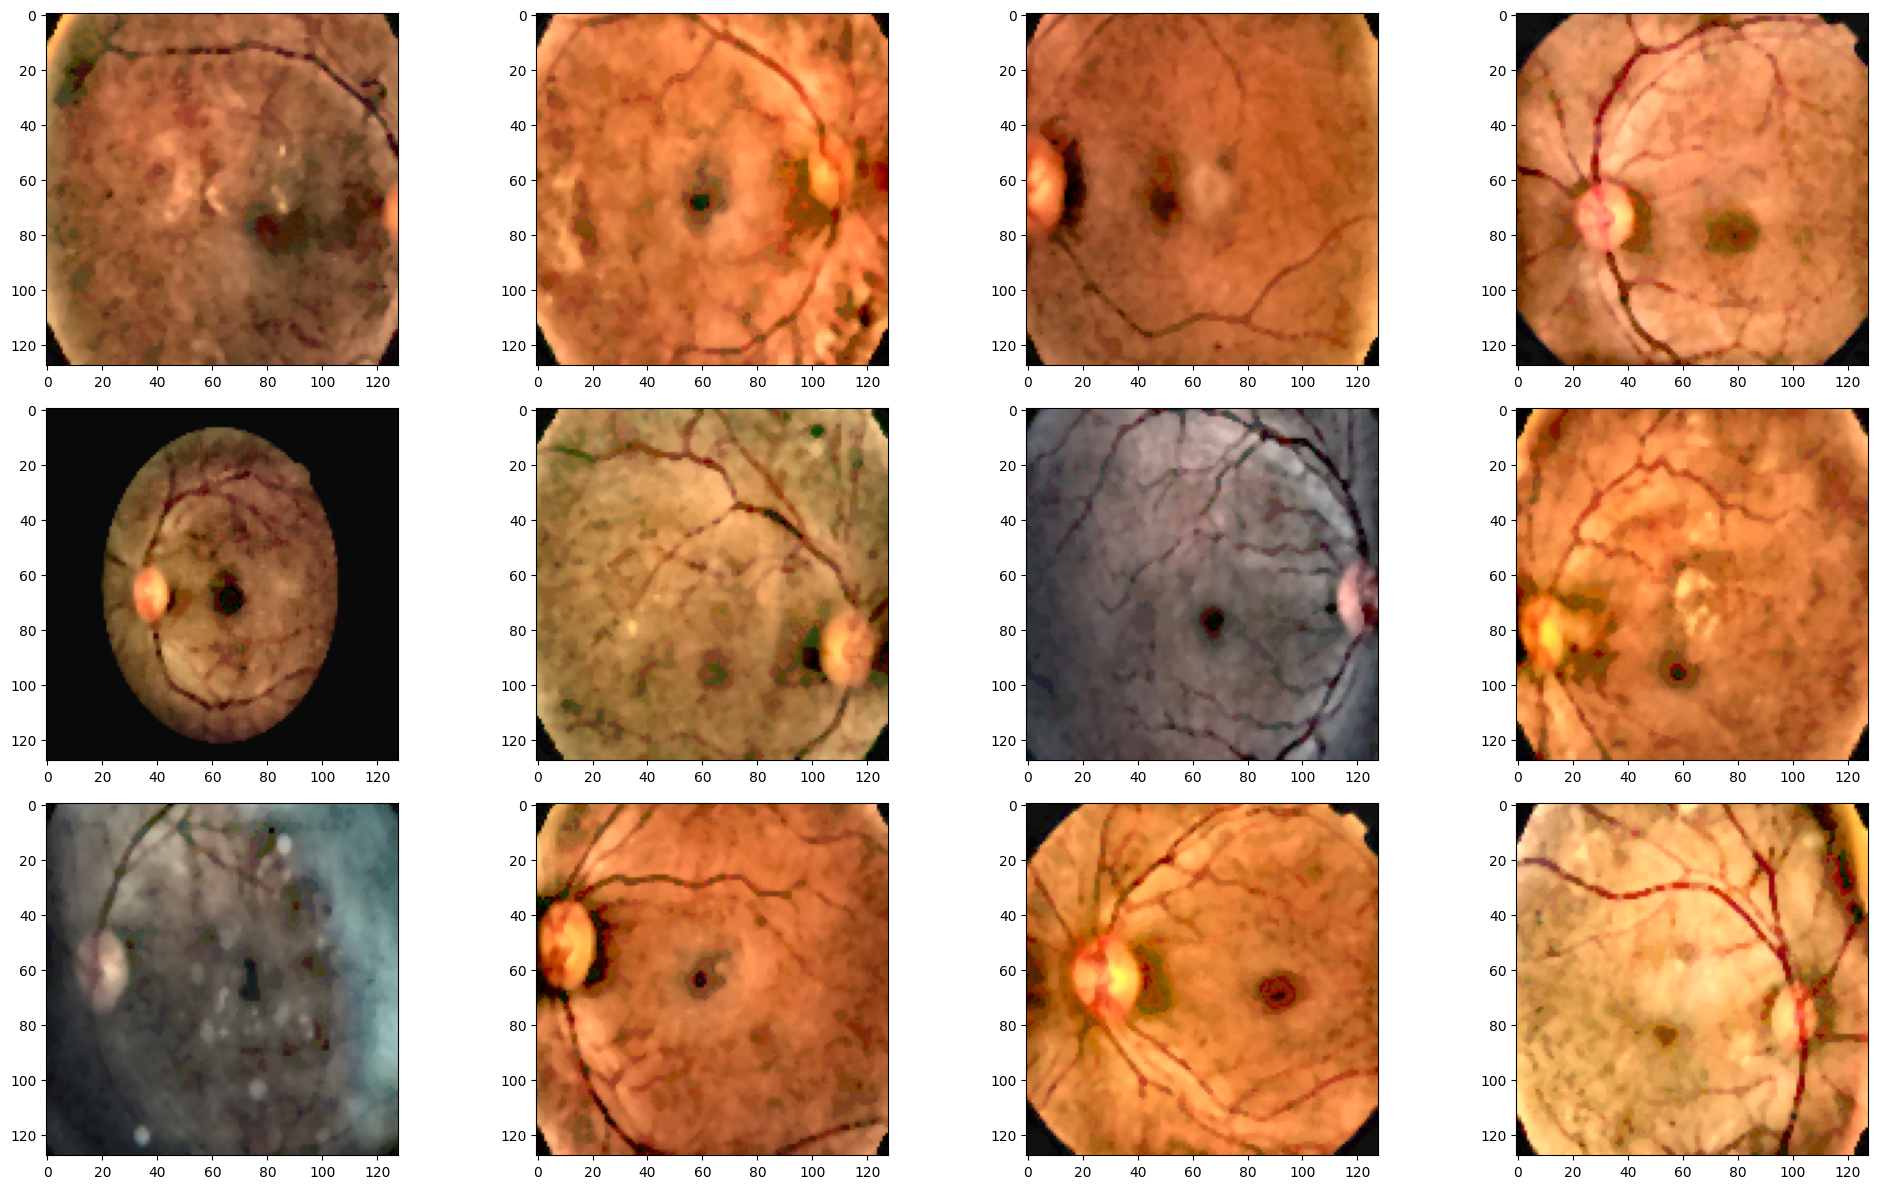

In [76]:
fig = plt.figure(figsize=(20,12))

for i in range(12):
    img = img_list[i]
    fig.add_subplot(3,4,i+1)
    plt.imshow(img)

plt.tight_layout()

In [77]:
# df['diagnosis']

### One Hot Encoding

In [116]:
y_train = pd.get_dummies(df['diagnosis']).values

In [79]:
# y_train

In [80]:
df['diagnosis'][1]

4

In [81]:
y_train[1]

array([False, False, False, False,  True])

In [82]:
y_train_son = np.ones(y_train.shape, dtype='uint8')

In [83]:
# y_train_son

In [84]:
y_train_son[:,4] = y_train[:,4]

In [85]:
# y_train_son

In [86]:
import numpy as np

In [87]:
np.logical_or(0,0)

False

In [88]:
np.logical_or(1,0)

True

In [89]:
np.logical_or(0,1)

True

In [90]:
np.logical_or(1,1)

True

In [91]:
np.logical_and(0,1)

False

In [92]:
np.logical_and(1,1)

True

In [93]:
for i in range(3,-1,-1):
    y_train_son[:,i] = np.logical_or(y_train[:,i], y_train_son[:,i+1])

In [94]:
# y_train_son

In [95]:
# y_train

In [96]:
x_train = np.array(img_list)

In [97]:
x_train.shape

(3662, 128, 128, 3)

In [98]:
y_train_son.shape

(3662, 5)

In [99]:
from sklearn.model_selection import train_test_split

x_train, x_val , y_train, y_val = train_test_split(x_train,
                                                   y_train_son,
                                                   test_size=0.15,
                                                   random_state=2019,
                                                   shuffle=True)

In [100]:
x_train.shape, x_val.shape , y_train.shape, y_val.shape

((3112, 128, 128, 3), (550, 128, 128, 3), (3112, 5), (550, 5))

In [101]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(horizontal_flip=True,vertical_flip=True)
data_generator = datagen.flow(x_train,y_train,batch_size=2,seed=2020)

In [102]:

from tensorflow.keras.applications import EfficientNetB5


In [103]:
örnek_model = EfficientNetB5()

In [104]:
#örnek_model.summary()

In [105]:
örnek_model2 = EfficientNetB5(include_top=False)
#örnek_model2.summary()

In [106]:
from keras.models import Sequential
from keras import layers

model = Sequential()
model.add(EfficientNetB5(weights='imagenet',include_top=False, input_shape=(128,128,3)))
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(5, activation='sigmoid'))


In [107]:
from keras.optimizers import Adam
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.00005), metrics=['accuracy'])


In [108]:
from keras.callbacks import ReduceLROnPlateau

lr = ReduceLROnPlateau(monitor = 'val_loss',
                      patience = 3,
                      verbose = 1,
                      mode='auto',
                      factor=0.25,
                      min_lr=0.000001)

In [109]:
history = model.fit(data_generator,
                             steps_per_epoch = 1000,
                             epochs = 30,
                             validation_data = (x_val,y_val),
                             callbacks = [lr])


Epoch 1/30
1000/1000 [==============================] - 128s 107ms/step - loss: 0.3670 - accuracy: 0.9260 - val_loss: 0.3809 - val_accuracy: 0.9236 - lr: 5.0000e-05
Epoch 2/30
1000/1000 [==============================] - 102s 102ms/step - loss: 0.2563 - accuracy: 0.9895 - val_loss: 0.3609 - val_accuracy: 0.9764 - lr: 5.0000e-05
Epoch 3/30
1000/1000 [==============================] - 100s 100ms/step - loss: 0.2181 - accuracy: 0.9905 - val_loss: 0.3386 - val_accuracy: 0.9982 - lr: 5.0000e-05
Epoch 4/30
1000/1000 [==============================] - 99s 99ms/step - loss: 0.2010 - accuracy: 0.9875 - val_loss: 0.2747 - val_accuracy: 0.9982 - lr: 5.0000e-05
Epoch 5/30
1000/1000 [==============================] - 99s 99ms/step - loss: 0.1817 - accuracy: 0.9920 - val_loss: 0.2793 - val_accuracy: 1.0000 - lr: 5.0000e-05
Epoch 6/30
1000/1000 [==============================] - 102s 102ms/step - loss: 0.1729 - accuracy: 0.9935 - val_loss: 0.3059 - val_accuracy: 0.9982 - lr: 5.0000e-05
Epoch 7/30
100

In [110]:
# History'den eğitim ve doğrulama metriklerini alma
history_dict = history.history

In [111]:
# Eğitim ve doğrulama kaybı (loss)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

In [112]:
# Eğitim ve doğrulama doğruluğu (accuracy)
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

In [113]:
epochs = range(1, len(loss_values) + 1)

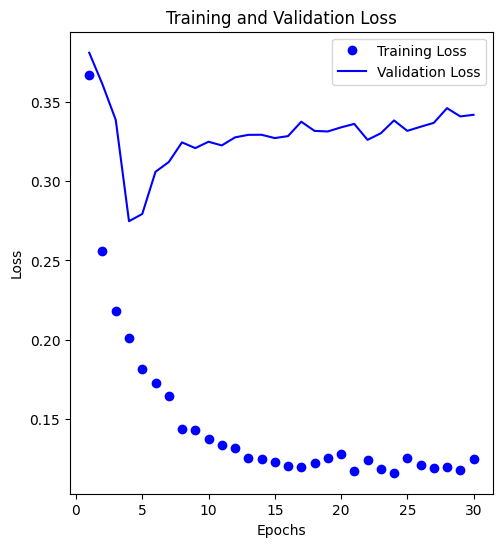

In [114]:
# Kayıp (Loss) Grafiği
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Training Loss')  # 'bo' mavi noktalar
plt.plot(epochs, val_loss_values, 'b', label='Validation Loss')  # 'b' mavi çizgi
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

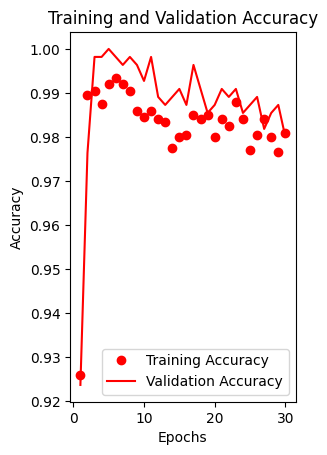

In [115]:
# Doğruluk (Accuracy) Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_values, 'ro', label='Training Accuracy')  # 'ro' kırmızı noktalar
plt.plot(epochs, val_acc_values, 'r', label='Validation Accuracy')  # 'r' kırmızı çizgi
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [126]:
os.chdir("..")


In [135]:
import numpy as np
from tensorflow.keras.preprocessing import image

file_name = "dataset/train_images/a28bfb772f50.png"


# Görüntüyü yükle ve yeniden boyutlandır
img = image.load_img(file_name, target_size=(128, 128))
img_array = image.img_to_array(img)

# Normalize et
img_array = img_array / 255.0

# Batch boyutu ekle (1, 128, 128, 3)
img_array = np.expand_dims(img_array, axis=0)

# Tahmin yap
predictions = model.predict(img_array)

print("Tahmin sonuçları:", predictions)


1/1 [==============================] - 0s 32ms/step
Tahmin sonuçları: [[0.9872038  0.8475021  0.69678974 0.66517293 0.5523483 ]]


In [138]:
import json
import numpy as np
from tensorflow.keras.models import model_from_config

def fix_json_serialization(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if hasattr(value, "numpy"):  # Tensor ise
        return value.numpy().tolist()
    return value

# Model konfigürasyonunu al
config = model.get_config()

# JSON'a uygun hale getir
fixed_config = json.loads(json.dumps(config, default=fix_json_serialization))

# Sequential modelse model_from_config ile tekrar yükle
from tensorflow.keras.models import Sequential
fixed_model = Sequential.from_config(fixed_config)

# Ağırlıkları aktar
fixed_model.set_weights(model.get_weights())

# Kaydet
fixed_model.save("output/efficientnet_fixed_model.h5")
